<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/1.0%20Data_Engineering%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The dataset for this project is stored, as an excel file, in an AWS S3 datalake, and streamed into a pandas dataframe. It is thereafter exported, without changes, into a Postrges data warehouse table; `fact_online_retail`, acting as a backup of the excel file and main reference for all data queries and table views.

In [1]:
!pip install openpyxl pyarrow s3fs

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
from google.colab import userdata

os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"

excel_url = "s3://sales-data-analytics-portfolio-2026/online+retail/Online Retail.xlsx"

print("Streaming excel file directly from AWS S3...")
txn_df = pd.read_excel(excel_url, engine = "openpyxl")

print(f'\nSuccessfully loaded {len(txn_df)} rows from Excel file')
print()
txn_df.info()
print()
txn_df.head()

Streaming excel file directly from AWS S3...

Successfully loaded 541909 rows from Excel file
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


With data successfully imported back into a DataFrame from an SQL table as presented above, data cleaning flags were added as new columns, preserving all rows, and ensuring the `v_clean_sales_analytics` view uses column filters to omit data issues, and serves an intermediary between the `fact_online_retail` table and the creation of database views, and pandas dataframes.

In [27]:
# 1.0 Formating InvoiceNo as interger and adding 'Cancelled' transaction flagging column

  # Assigning cancelled column
cancelled_transaction = txn_df['InvoiceNo'].astype("str").str.upper().str.contains("C")
txn_df['IsCancelled'] = np.where(cancelled_transaction, 1, 0)

# 2.0 Characterising stockcodes
numeric_list = list(range(10))
numeric_list = [str(x) for x in numeric_list]
unique_codes = txn_df['StockCode'].unique()
other_codes = []

for code in unique_codes:
    # Pull first 5 characters, as first 5 are expected to be numeric
    for x in str(code)[0:5]:
        validation = ""
        # Looping through each of the first 5, when non-integer is detected, flag code as other code
        if x in numeric_list:
            validation = True
        else:
            validation = False
            # Checking if such a code is already in list to avoid duplicates and adding to list if doesn't exist
            if code not in other_codes:
                other_codes.append(code)

  # Assigning column to identity other codes
is_other_code = txn_df["StockCode"].isin(other_codes)
txn_df["IsOtherCode"] = np.where(is_other_code, 1, 0)

# 3.0 Assigning negative quantities as product returns and flagging negative prices
returned = txn_df["Quantity"] < 0
txn_df["IsReturned"] = np.where(returned, 1, 0)

neg_price = txn_df["UnitPrice"] < 0
txn_df["IsNegativePrice"] = np.where(neg_price, 1, 0)

# 4.0 Flagging null CustomerID values as "Guest"
guest = txn_df["CustomerID"].isna()
txn_df["IsGuest"] = np.where(guest, 1,0)

#Converting columns to str to handle mixed variable for parquet upload
object_cols = txn_df.select_dtypes("object").columns

for column in object_cols:
    txn_df[column] = txn_df[column].astype("str")

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail.parquet"

print("Uploading dataset with data cleaning filters as parquet file to S3")
txn_df.to_parquet(parquet_url, index = False)
print('\nSuccessfully uploaded parquet file to S3')

df = pd.read_parquet(parquet_url)
print("\nSuccessfully streamed parquet file from S3 for preview:")

print("\nPreview of parquet_file uploaded to S3")
print()
df_review.info()

Uploading dataset with data cleaning filters as parquet file to S3

Successfully uploaded parquet file to S3

Successfully streamed parquet file from S3 for preview:

Preview of parquet_file uploaded to S3

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        541909 non-null  object        
 1   StockCode        541909 non-null  object        
 2   Description      541909 non-null  object        
 3   Quantity         541909 non-null  int64         
 4   InvoiceDate      541909 non-null  datetime64[ns]
 5   UnitPrice        541909 non-null  float64       
 6   CustomerID       406829 non-null  float64       
 7   Country          541909 non-null  object        
 8   IsCancelled      541909 non-null  int64         
 9   IsOtherCode      541909 non-null  int64         
 10  IsReturned       541909 non-n

Exploratory data analysis revealed that the data initially had some data issue that required attention, and includes cancelled transactions, returned items, and codes related other business transactions unrelated to sales. Notably, several transactions had no customer ids, categorised as `Guests`, which along with the other issues identified, were excluded for the analysis, as informed prediction cannot be made on clients without an identity or documented history.

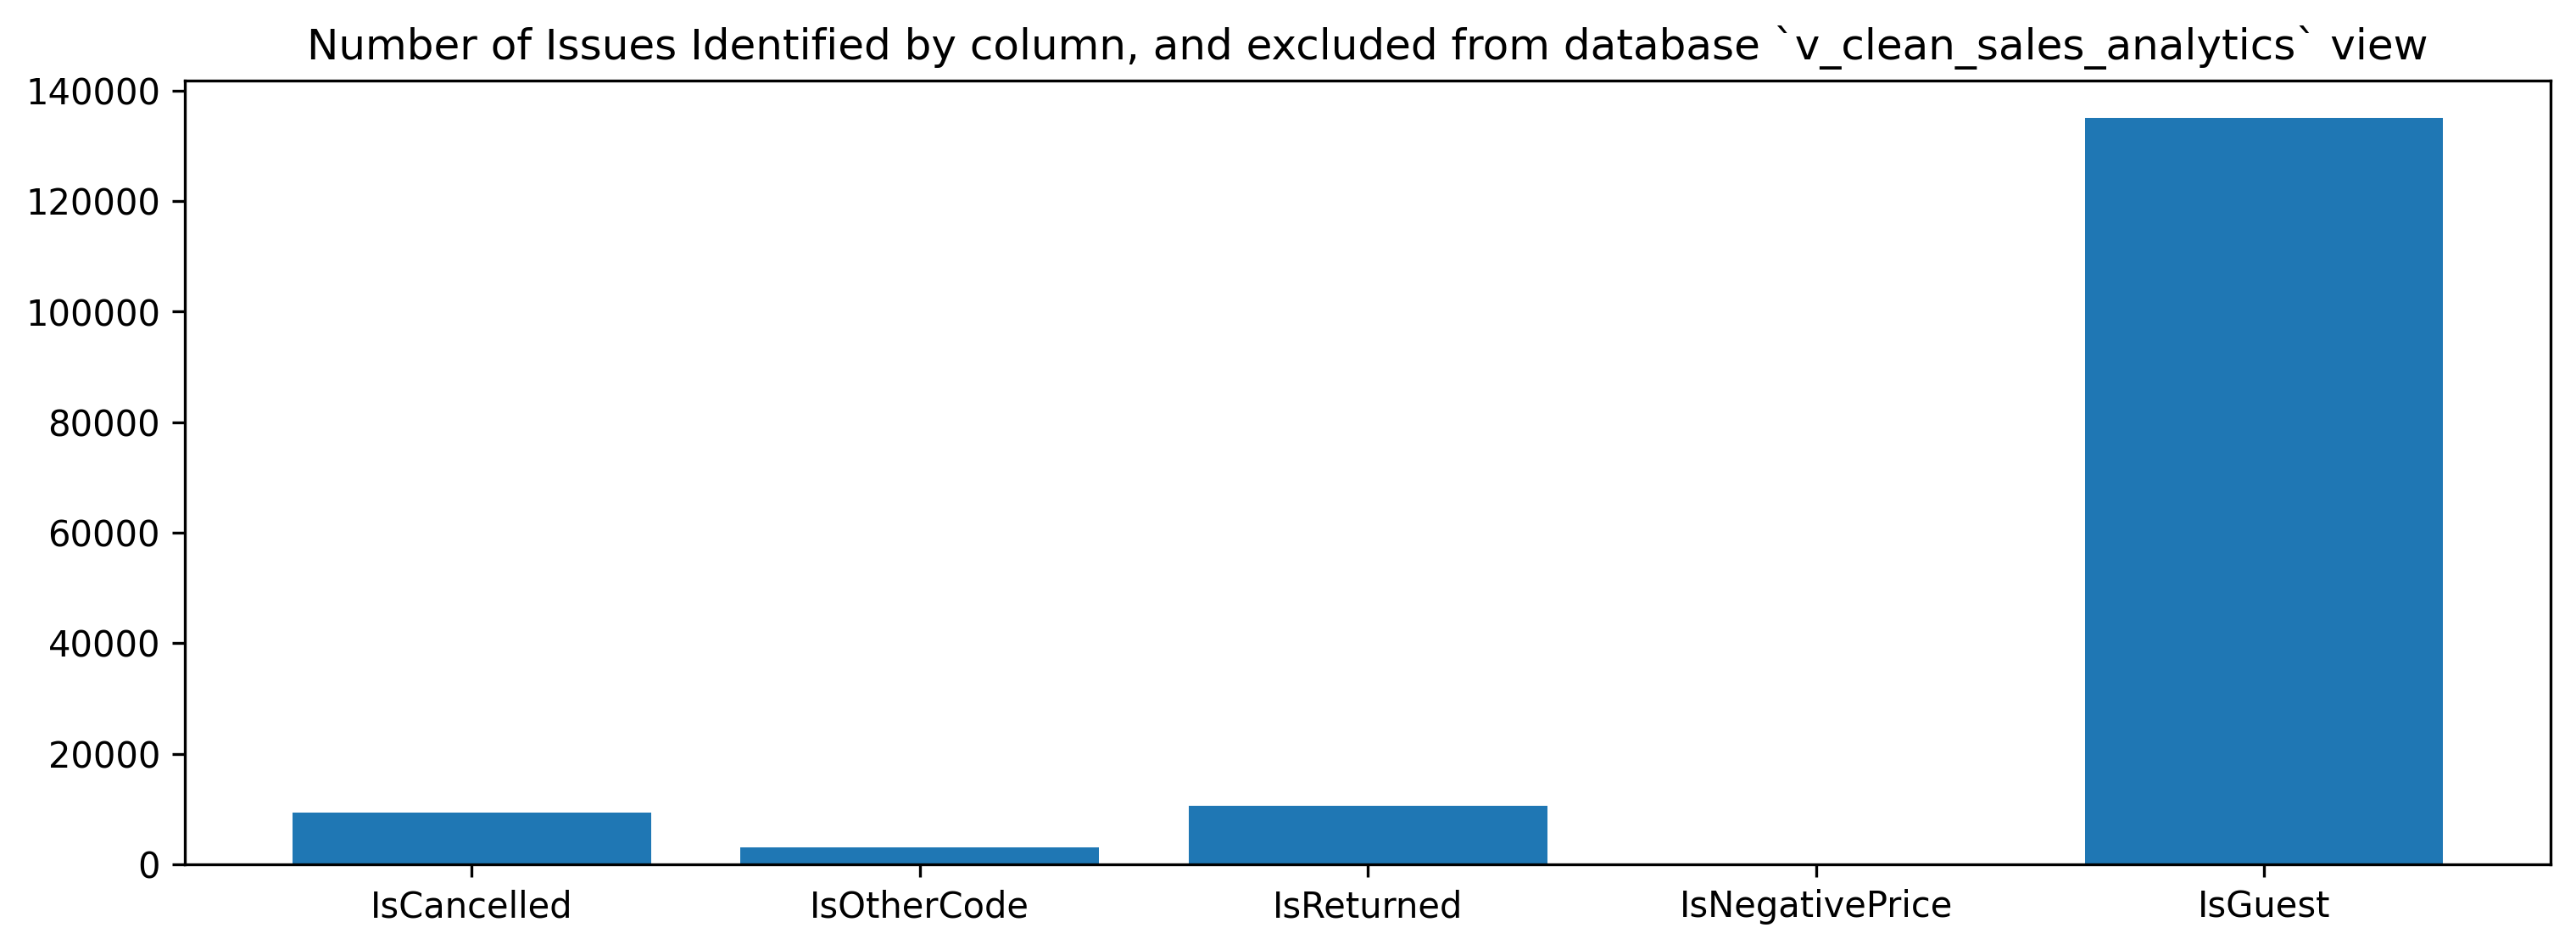

,IsCancelled,IsOtherCode,IsReturned,IsNegativePrice,IsGuest
0,9288,2995,10624,2,135080


In [30]:
import matplotlib.pyplot as plt

cols = ["IsCancelled", "IsOtherCode", "IsReturned", "IsNegativePrice", "IsGuest"]

column_name = []
num = []
for column in cols:
    count = df[column].sum()

    column_name.append(column)
    num.append(count)

plt.figure(figsize = (12,4), dpi = 300)
plt.bar(column_name, num)
plt.title("Number of Issues Identified by column, and excluded from database `v_clean_sales_analytics` view")
plt.show()

pd.DataFrame(df[cols].sum(axis = 0)).transpose()

In [40]:
for column in cols:
    df = df[df[column] == 0]

# Uploading clean dataframe to s3

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail_clean.parquet"

print("\nUploading clean dataset as parquet file to S3...")
df.to_parquet(parquet_url, index = False)

print(f'\nSuccessfully uploaded {len(df)} rows of clean data as parquet file to S3')

print("\nPreview of data cleaned and uploaded to S3")
print()
df.info()


Uploading clean dataset as parquet file to S3...

Successfully uploaded 396370 rows of clean data as parquet file to S3

Preview of data cleaned and uploaded to S3

<class 'pandas.core.frame.DataFrame'>
Index: 396370 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        396370 non-null  object        
 1   StockCode        396370 non-null  object        
 2   Description      396370 non-null  object        
 3   Quantity         396370 non-null  int64         
 4   InvoiceDate      396370 non-null  datetime64[ns]
 5   UnitPrice        396370 non-null  float64       
 6   CustomerID       396370 non-null  float64       
 7   Country          396370 non-null  object        
 8   IsCancelled      396370 non-null  int64         
 9   IsOtherCode      396370 non-null  int64         
 10  IsReturned       396370 non-null  int64         
 11  IsNegativePrice  3963